<div style="text-align: center;">

# Sustainability Aware Asset Management  
# Portfolio Allocation with a Carbon Objective  

<br>

**Course:** Sustainability Aware Asset Management<br>
**Instructor:** Professor Eric Jondeau<br> 
**Academic Year:** 2025–2026<br>  

<br>

**Group Members**  
Matteo Piras<br>
Tomas Papuga<br> 
Marco d'Amico<br>
Roberto Berardi<br> 

<br>

**Submission Date:** May 2026  

</div>

# Part I- Standard Portfolio Allocation
## 1) Data Cleaning

### Missing Prices and Datastream Error Rows

The raw datasets are direct exports from Datastream and may contain structural inconsistencies that must be addressed before any financial analysis.

Some ISIN codes are flagged with `$$ER`, indicating that Datastream could not correctly match the requested security (for example, due to share class mismatches or unavailable data). These rows do not contain valid financial information and are therefore removed from all datasets.

We then standardize the structure of each file by:
- Converting ISIN codes to a consistent string format,
- Removing non-numeric columns such as firm names,
- Transposing the data so that dates form the index and firms form the columns,
- Converting all values to numeric format.

At this stage, we only correct structural and data-quality issues. No economic filtering (region, carbon availability, liquidity, etc.) is applied yet. 

In [25]:
import pandas as pd
import numpy as np

print("Starting finalized data preparation process...")

# --------------------------------------------------------
# 1. Setup and Static Data Filtering
# --------------------------------------------------------
# Load the static dataset to identify the initial investment universe
static_df = pd.read_excel('Data_2026/Static_2025.xlsx')
static_df['ISIN'] = static_df['ISIN'].astype(str).str.strip()

# Isolate firms belonging to the Emerging Markets (EM) region
em_firms = static_df[static_df['Region'] == 'EM'].copy()
valid_em_isins = em_firms['ISIN'].unique().tolist()

def load_and_transpose(filepath, is_monthly=False):
    """
    Standardizes Datastream Excel exports into time-series DataFrames.
    Removes error flags ($$ER) and transposes firms to columns.
    """
    df = pd.read_excel(filepath)
    # Rule: Explicitly delete ISINs with Datastream errors ($$ER)
    df = df[~df['ISIN'].astype(str).str.contains(r'\$\$ER', na=False)]
    df['ISIN'] = df['ISIN'].astype(str).str.strip()
    df.set_index('ISIN', inplace=True)
    
    if 'NAME' in df.columns:
        df.drop(columns=['NAME'], inplace=True)
    
    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors='coerce')
    
    # Handle indexing based on data frequency (Monthly for RI, Yearly for Carbon)
    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        df_t.index = df_t.index.astype(int)
    return df_t

print("Static data loaded and EM firms identified.")

Starting finalized data preparation process...
Static data loaded and EM firms identified.


### Missing Values: Beginning, Middle, and End of Sample

The datasets contain different types of missing observations that must be handled carefully to ensure consistent return estimation and avoid distortions in portfolio construction.

First, missing values at the beginning of the sample typically correspond to firms that were not yet listed or had not started reporting data. In this case, no correction is applied.

Second, missing values between two available observations usually reflect temporary reporting gaps or data issues. To preserve continuity in the return series, we apply a forward-fill procedure to bridge these internal gaps.

Third, missing values at the end of the sample generally correspond to firm delisting or default events. In such cases, the price is assumed to drop to zero, implying a realized return of −100% in the month following the last valid observation. All subsequent periods are set to missing values to avoid artificially lowering volatility.

This treatment ensures a realistic handling of firm exits while maintaining the integrity of the historical return series.

In [26]:
# --------------------------------------------------------
# 2. Return Index (RI) Processing with Delisting Logic
# --------------------------------------------------------
ri_monthly = load_and_transpose('Data_2026/DS_RI_T_USD_M_2025.xlsx', is_monthly=True)
ri_em = ri_monthly[[isin for isin in valid_em_isins if isin in ri_monthly.columns]].copy()

# Rule: Treat prices < 0.5 as missing values to avoid extreme returns from penny stocks
ri_em[ri_em < 0.5] = np.nan

# CRITICAL: Identify the real last valid date BEFORE filling gaps.
# This ensures that delisting (final disappearance) is not masked by forward-filling.
real_last_valid_dates = ri_em.apply(lambda col: col.last_valid_index())

# Rule: Fill gaps between available values (Forward Fill) to bridge misreporting
ri_em_filled = ri_em.ffill()
returns_em = ri_em_filled.pct_change()

# Applying Precise Delisting Logic: -100% loss followed by NaNs
for isin in returns_em.columns:
    last_date = real_last_valid_dates[isin]
    if pd.notna(last_date):
        last_pos = returns_em.index.get_loc(last_date)
        
        # If the firm disappears before the end of the sample, acknowledge the loss
        if last_pos < len(returns_em) - 1:
            # Force -100% return in the month following the last valid price
            returns_em.iloc[last_pos + 1, returns_em.columns.get_loc(isin)] = -1.0
            
            # Ensure post-delisting periods are NaN (not zero) to avoid stale price/low volatility bias
            if last_pos + 1 < len(returns_em) - 1:
                returns_em.iloc[last_pos + 2:, returns_em.columns.get_loc(isin)] = np.nan
    else:
        # Mark firms with no valid data for complete removal
        returns_em[isin] = np.nan

C:\Users\tomas\AppData\Local\Temp\ipykernel_1104\3561478211.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_em = ri_em_filled.pct_change()


### Carbon Data Preparation and Validation

Scope 1 and Scope 2 carbon emissions data are first loaded from the Datastream files and transformed into annual time-series format. The sample is then restricted to firms belonging to the Emerging Markets universe.

To account for reporting gaps across years, carbon emissions data are forward-filled. This means that when a firm does not report emissions in a given year, the most recent available observation is carried forward.

After this step, firms with no available data at all are removed from the corresponding datasets. The same cleaning rule is also applied to the returns matrix, so that firms without usable information are excluded from the analysis.

Finally, a validation summary is printed to check the dimensions of the returns, Scope 1, and Scope 2 datasets before proceeding with the next steps.

In [27]:

scope1_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_1_Y_2025.xlsx', is_monthly=False)
scope2_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_2_Y_2025.xlsx', is_monthly=False)

# Filter for EM and apply Forward Fill for reporting gaps between years
scope1_em = scope1_em[[isin for isin in valid_em_isins if isin in scope1_em.columns]].copy().ffill()
scope2_em = scope2_em[[isin for isin in valid_em_isins if isin in scope2_em.columns]].copy().ffill()

# Rule: Physically delete firms with no associated data from all tables
returns_em.dropna(how='all', axis=1, inplace=True)
scope1_em.dropna(how='all', axis=1, inplace=True)
scope2_em.dropna(how='all', axis=1, inplace=True)

print("Data Validation Overview:")
print(f"- Returns Matrix: {returns_em.shape[0]} months, {returns_em.shape[1]} firms")
print(f"- Scope 1/2 Matrices: {scope1_em.shape[0]} years")
display(returns_em.head())

Data Validation Overview:
- Returns Matrix: 314 months, 668 firms
- Scope 1/2 Matrices: 27 years


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-31,0.176511,-0.051861,-0.004877,NaN,-0.044175,-0.067245,0.023986,-0.249634,0.011906,NaN,...,-0.115161,-0.049527,0.096965,0.067794,0.205596,0.099568,-0.080722,0.125341,0.021174,-0.114179
2000-02-29,0.050002,0.178923,0.039543,NaN,-0.045539,-0.036328,-0.107794,0.005452,0.043492,NaN,...,-0.037800,-0.100608,-0.326248,0.028928,-0.053481,-0.084315,-0.062844,-0.181598,0.018379,-0.023150
2000-03-31,-0.023552,-0.105072,-0.002113,NaN,0.313941,-0.130625,0.152061,0.014002,0.002361,NaN,...,-0.067887,-0.034040,-0.044066,-0.176088,-0.126866,0.073915,-0.054382,-0.038462,-0.142989,-0.104274
2000-04-28,-0.016173,-0.161842,-0.071188,NaN,-0.001350,-0.077311,-0.108617,-0.032966,-0.020143,NaN,...,-0.034586,-0.042240,-0.172342,-0.129131,-0.035409,-0.208833,-0.030503,-0.224615,-0.095572,0.003496


### Dynamic Investment Set Construction (10-Year Rolling Window)

After cleaning the data, we construct the investment universe dynamically for each portfolio formation year.

For each year 
𝑌
Y, we use a 10-year rolling estimation window (from January 
𝑌
−
9
Y−9 to December 
𝑌
Y) to determine firm eligibility. The portfolio formed at the end of year 
𝑌
Y is implemented during year 
𝑌
+
1
Y+1.

A firm is included in the investment set only if it satisfies all of the following conditions:

Price availability at formation date:
The firm must have a valid price at the end of year 
𝑌
Y. Firms with missing or invalid prices at the portfolio formation date are excluded.

Liquidity condition (stale price filter):
Over the 10-year estimation window, the proportion of zero monthly returns must not exceed 50%. This ensures that illiquid firms do not artificially reduce estimated portfolio volatility.

Carbon data availability:
Both Scope 1 and Scope 2 emissions data must be available at the end of year 
𝑌
Y. This guarantees consistency between the financial allocation and the sustainability analysis.

The resulting set of eligible firms is stored for each holding year 
𝑌
+
1
Y+1, forming a sequence of dynamically updated investment universes.

In [28]:
print("Initiating dynamic filtering for 10-year rolling windows...")

# Step 5: Dynamic Universe Construction
# We identify eligible firms for each year based on historical liquidity and ESG disclosure.
valid_investment_sets = {}
estimation_years = range(2009, 2025)

for Y in estimation_years:
    # Define the 10-year rolling estimation window (Dec Y-9 to Dec Y)
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date]
    window_prices = ri_em.loc[start_date:end_date]
    
    valid_isins_for_year = []
    
    for isin in returns_em.columns:
        # Rule: Price Availability at end of year Y
        # Exclude firms missing a valid price (>0.5 USD) at the portfolio formation date.
        if pd.isna(window_prices[isin].iloc[-1]):
            continue
            
        # Rule: Stale Price / Liquidity Filter
        # Calculate the ratio of months with zero returns to avoid illiquid assets.
        total_valid_months = window_returns[isin].notna().sum()
        if total_valid_months < 36:
            continue
        
        # Exclude if the firm has no price movement for > 50% of the window.
        if (window_returns[isin] == 0.0).sum() / total_valid_months > 0.5:
            continue
            
        # Rule: Carbon Data Availability for Year Y
        # Both Scope 1 and Scope 2 data must be present for the firm to be eligible.
        if Y in scope1_em.index and Y in scope2_em.index:
            if isin in scope1_em.columns and isin in scope2_em.columns:
                if not pd.isna(scope1_em.loc[Y, isin]) and not pd.isna(scope2_em.loc[Y, isin]):
                    valid_isins_for_year.append(isin)
    
    # Store the investment set for the subsequent holding period (Y + 1)
    valid_investment_sets[Y + 1] = valid_isins_for_year
    print(f"Holding Year {Y+1}: {len(valid_isins_for_year)} firms identified.")

print("\nInvestment universes constructed successfully.")

Initiating dynamic filtering for 10-year rolling windows...
Holding Year 2010: 66 firms identified.
Holding Year 2011: 160 firms identified.
Holding Year 2012: 198 firms identified.
Holding Year 2013: 224 firms identified.
Holding Year 2014: 245 firms identified.
Holding Year 2015: 267 firms identified.
Holding Year 2016: 297 firms identified.
Holding Year 2017: 334 firms identified.
Holding Year 2018: 381 firms identified.
Holding Year 2019: 416 firms identified.
Holding Year 2020: 463 firms identified.
Holding Year 2021: 504 firms identified.
Holding Year 2022: 542 firms identified.
Holding Year 2023: 571 firms identified.
Holding Year 2024: 579 firms identified.
Holding Year 2025: 566 firms identified.

Investment universes constructed successfully.


# PARTE 2

In [29]:
print("Calculating Expected Returns and Covariance Matrices...")

# --------------------------------------------------------
# 6. Estimation of Expected Returns and Covariance Matrices
# --------------------------------------------------------
# Using the formulas exactly:
#
# mu_hat_Y = (1/tau) * sum R_t
#
# Sigma_Y = (1/tau) * sum (R_t - mu_hat_Y)'(R_t - mu_hat_Y)
#
# Missing values are replaced by 0 before computation.

mu_estimates = {}
sigma_estimates = {}

estimation_years = range(2009, 2025)

for Y in estimation_years:

    holding_year = Y + 1
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # 10-year estimation window
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"

    window_returns = returns_em.loc[start_date:end_date, valid_isins].copy()

    # Replace missing returns with 0
    window_returns = window_returns.fillna(0)

    # number of observations (should be 120 months)
    tau = window_returns.shape[0]

    # --------------------------------------------------------
    # Expected Returns (formula)
    # --------------------------------------------------------
    mu_hat_Y = window_returns.sum(axis=0) / tau

    # --------------------------------------------------------
    # Covariance Matrix (formula)
    # --------------------------------------------------------
    R = window_returns.to_numpy()            # tau x N
    mu = mu_hat_Y.to_numpy().reshape(1, -1)  # 1 x N

    # center returns
    R_centered = R - mu

    # covariance formula
    Sigma_array = (R_centered.T @ R_centered) / tau

    # convert back to dataframe
    Sigma_Y = pd.DataFrame(
        Sigma_array,
        index=window_returns.columns,
        columns=window_returns.columns
    )

    mu_estimates[holding_year] = mu_hat_Y
    sigma_estimates[holding_year] = Sigma_Y

    print(
        f"Holding Year {holding_year}: "
        f"{len(valid_isins)} firms, "
        f"tau={tau}, "
        f"mu size={mu_hat_Y.shape[0]}, "
        f"Sigma shape={Sigma_Y.shape}"
    )

print("\nExpected returns and covariance matrices computed successfully.")

# --------------------------------------------------------
# Example check
# --------------------------------------------------------
example_year = 2014
if example_year in mu_estimates and example_year in sigma_estimates:
    print(f"\nExample: Holding Year {example_year}")
    display(mu_estimates[example_year].head())
    display(sigma_estimates[example_year].iloc[:5, :5])

Calculating Expected Returns and Covariance Matrices...
Holding Year 2010: 66 firms, tau=120, mu size=66, Sigma shape=(66, 66)
Holding Year 2011: 160 firms, tau=120, mu size=160, Sigma shape=(160, 160)
Holding Year 2012: 198 firms, tau=120, mu size=198, Sigma shape=(198, 198)
Holding Year 2013: 224 firms, tau=120, mu size=224, Sigma shape=(224, 224)
Holding Year 2014: 245 firms, tau=120, mu size=245, Sigma shape=(245, 245)
Holding Year 2015: 267 firms, tau=120, mu size=267, Sigma shape=(267, 267)
Holding Year 2016: 297 firms, tau=120, mu size=297, Sigma shape=(297, 297)
Holding Year 2017: 334 firms, tau=120, mu size=334, Sigma shape=(334, 334)
Holding Year 2018: 381 firms, tau=120, mu size=381, Sigma shape=(381, 381)
Holding Year 2019: 416 firms, tau=120, mu size=416, Sigma shape=(416, 416)
Holding Year 2020: 463 firms, tau=120, mu size=463, Sigma shape=(463, 463)
Holding Year 2021: 504 firms, tau=120, mu size=504, Sigma shape=(504, 504)
Holding Year 2022: 542 firms, tau=120, mu size=5

ISIN
BRBBASACNOR3    0.024255
BRBBDCACNPR8    0.022722
BRBRFSACNOR8    0.032435
BRBRKMACNPA4    0.015174
BRCESPACNPB4    0.011178
dtype: float64

ISIN,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4
ISIN,,,,,
BRBBASACNOR3,0.015590,0.010866,0.008129,0.007731,0.006893
BRBBDCACNPR8,0.010866,0.012099,0.008446,0.007131,0.005413
BRBRFSACNOR8,0.008129,0.008446,0.014663,0.006491,0.005183
BRBRKMACNPA4,0.007731,0.007131,0.006491,0.019695,0.004748
BRCESPACNPB4,0.006893,0.005413,0.005183,0.004748,0.014449


Starting Part 2.2 - Minimum Variance Portfolio...
Risk-free monthly series loaded successfully.


Unnamed: 0
2000-01-01    0.0041
2000-02-01    0.0043
2000-03-01    0.0047
2000-04-01    0.0046
2000-05-01    0.0050
Name: RF, dtype: float64

Holding Year 2014: optimized with 245 firms.
Holding Year 2015: optimized with 267 firms.
Holding Year 2016: optimized with 297 firms.
Holding Year 2017: optimized with 334 firms.
Holding Year 2018: optimized with 381 firms.
Holding Year 2019: optimized with 416 firms.
Holding Year 2020: optimized with 463 firms.
Holding Year 2021: optimized with 504 firms.
Holding Year 2022: optimized with 542 firms.
Holding Year 2023: optimized with 571 firms.
Holding Year 2024: optimized with 579 firms.
Holding Year 2025: optimized with 566 firms.

Monthly ex-post MV returns computed successfully.

Part 2.2 Summary Statistics:


,Minimum Variance Portfolio
Annualized Average Return,0.065119
Annualized Volatility,0.109135
Annualized Risk-Free Rate,0.017475
Annualized Excess Return,0.047644
Sharpe Ratio,0.436556
Minimum Monthly Return,-0.064619
Maximum Monthly Return,0.121609
Number of Months,144.000000



'Data_2026/PART_2_2_MIN_VARIANCE.xlsx' generated successfully.


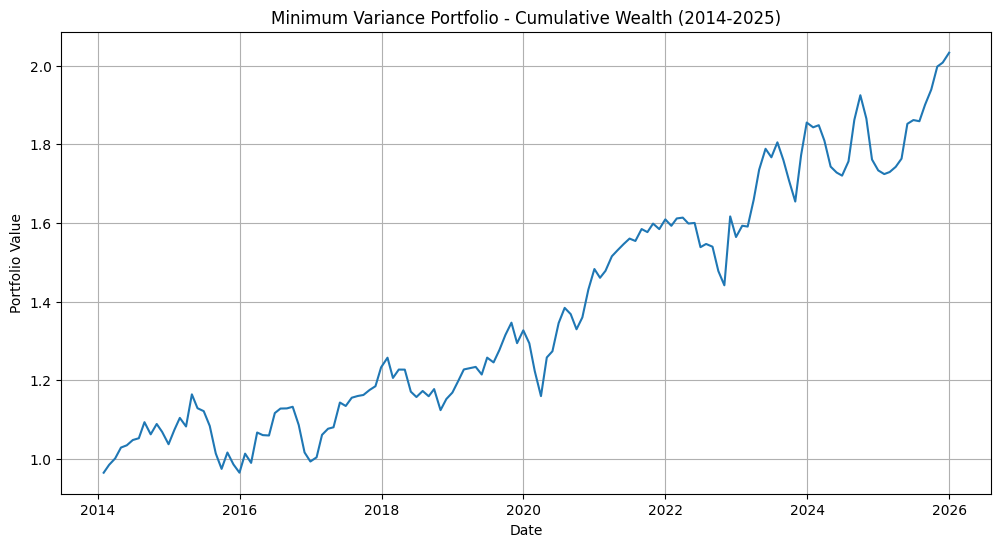

In [30]:
print("Starting Part 2.2 - Minimum Variance Portfolio...")

from scipy.optimize import minimize
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 7. Load monthly risk-free rate from uploaded Excel file
# --------------------------------------------------------
# We align RF exactly like your friend:
# - load monthly RF
# - convert YYYYMM to datetime
# - later convert both portfolio returns and RF to Period('M')
#   so the alignment is exact month by month

rf_df = pd.read_excel(
    'Data_2026/Risk_Free_Rate_2025.xlsx',
    sheet_name='F-F_Research_Data_Factors'
)

date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

rf_df = rf_df.dropna(subset=[date_col, rate_col]).copy()
rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(int).astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)

# Convert from percent to decimal
rf_series = pd.to_numeric(rf_df[rate_col], errors='coerce') / 100.0
rf_series = rf_series.dropna().sort_index()

print("Risk-free monthly series loaded successfully.")
display(rf_series.head())

# --------------------------------------------------------
# 8. Minimum Variance Portfolio Optimization
# --------------------------------------------------------
# PDF logic:
# - allocation decided at end of year Y
# - implemented over year Y+1
# - rebalance every year from Dec. 2013 to Dec. 2024
# => holding years go from 2014 to 2025
# --------------------------------------------------------

formation_years_22 = range(2013, 2025)   # 2013 ... 2024
holding_years_22 = range(2014, 2026)     # 2014 ... 2025

def solve_min_variance_weights(Sigma_Y):
    """
    Solve the long-only minimum variance problem:
        min w' Sigma w
        s.t. sum(w)=1, w_i >= 0
    """
    n = Sigma_Y.shape[0]

    if n == 1:
        return pd.Series([1.0], index=Sigma_Y.index)

    Sigma = Sigma_Y.to_numpy()

    def objective(w):
        return float(w @ Sigma @ w)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n
    x0 = np.repeat(1.0 / n, n)

    result = minimize(
        objective,
        x0=x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        print("WARNING: optimization failed, fallback to equal weights.")
        w_opt = x0
    else:
        w_opt = result.x
        w_opt = np.maximum(w_opt, 0)
        if w_opt.sum() > 0:
            w_opt = w_opt / w_opt.sum()
        else:
            w_opt = x0

    return pd.Series(w_opt, index=Sigma_Y.index)

# --------------------------------------------------------
# 9. Compute yearly optimal weights
# --------------------------------------------------------
mv_weights = {}
mv_year_summary = []

for Y in formation_years_22:
    holding_year = Y + 1

    if holding_year not in sigma_estimates:
        print(f"Holding Year {holding_year}: Sigma not available.")
        continue

    Sigma_Y = sigma_estimates[holding_year].copy()

    if Sigma_Y.shape[0] == 0:
        print(f"Holding Year {holding_year}: empty covariance matrix.")
        continue

    w_Y = solve_min_variance_weights(Sigma_Y)
    mv_weights[holding_year] = w_Y

    mv_year_summary.append({
        'Formation_Year_Y': Y,
        'Holding_Year_Y+1': holding_year,
        'Number_of_Firms': len(w_Y),
        'Weights_Sum': float(w_Y.sum()),
        'Min_Weight': float(w_Y.min()),
        'Max_Weight': float(w_Y.max())
    })

    print(f"Holding Year {holding_year}: optimized with {len(w_Y)} firms.")

# --------------------------------------------------------
# 10. Ex-post monthly performance with drifting weights
# --------------------------------------------------------
mv_portfolio_returns = []
mv_wealth_path = []

wealth = 1.0

for Y in formation_years_22:
    holding_year = Y + 1

    if holding_year not in mv_weights:
        continue

    current_weights = mv_weights[holding_year].copy()
    valid_isins = list(current_weights.index)

    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins
    ].copy()

    # consistent with your Part 2.1 estimation choice
    holding_returns = holding_returns.fillna(0.0)

    for dt, r_t in holding_returns.iterrows():
        rp_t = float((current_weights * r_t).sum())

        mv_portfolio_returns.append({
            'Date': dt,
            'Formation_Year_Y': Y,
            'Holding_Year': holding_year,
            'MV_Return': rp_t
        })

        wealth *= (1 + rp_t)
        mv_wealth_path.append({
            'Date': dt,
            'MV_Wealth': wealth
        })

        # drift weights to next month
        if (1 + rp_t) != 0:
            current_weights = current_weights * (1 + r_t) / (1 + rp_t)
            current_weights = current_weights.clip(lower=0)

            if current_weights.sum() > 0:
                current_weights = current_weights / current_weights.sum()

print("\nMonthly ex-post MV returns computed successfully.")

# --------------------------------------------------------
# 11. Build output tables
# --------------------------------------------------------
mv_returns_df = pd.DataFrame(mv_portfolio_returns).sort_values('Date')
mv_wealth_df = pd.DataFrame(mv_wealth_path).sort_values('Date')
mv_year_summary_df = pd.DataFrame(mv_year_summary)

if not mv_returns_df.empty:
    mv_returns_df.set_index('Date', inplace=True)

if not mv_wealth_df.empty:
    mv_wealth_df.set_index('Date', inplace=True)

if len(mv_weights) > 0:
    mv_weights_table = pd.concat(mv_weights, axis=1)
    mv_weights_table.columns.name = 'Holding_Year'
else:
    mv_weights_table = pd.DataFrame()

# --------------------------------------------------------
# 12. Align portfolio returns and RF exactly like your friend
# --------------------------------------------------------
if not mv_returns_df.empty:
    portfolio_oos_series = mv_returns_df['MV_Return'].copy()

    # enforce evaluation period exactly
    portfolio_oos_series = portfolio_oos_series.loc['2014-01-01':'2025-12-31']

    # convert both to monthly period index
    portfolio_oos_series.index = portfolio_oos_series.index.to_period('M')
    rf_series_period = rf_series.copy()
    rf_series_period.index = rf_series_period.index.to_period('M')

    # align exactly on the same months
    rf_oos = rf_series_period.loc[portfolio_oos_series.index]

    # build monthly table
    aligned_returns_df = pd.DataFrame({
        'MV_Return': portfolio_oos_series,
        'RF': rf_oos
    })

    aligned_returns_df['Excess_Return'] = aligned_returns_df['MV_Return'] - aligned_returns_df['RF']
else:
    aligned_returns_df = pd.DataFrame(columns=['MV_Return', 'RF', 'Excess_Return'])

# --------------------------------------------------------
# 13. Summary statistics with RF aligned correctly
# --------------------------------------------------------
# This now matches your friend's methodology:
# - arithmetic annualized average return
# - arithmetic annualized average RF
# - annualized excess return
# - annualized volatility
# - Sharpe = annualized excess / annualized volatility

def compute_summary_stats_with_rf_friend_style(returns_df):
    if returns_df.empty:
        return pd.Series({
            'Annualized Average Return': np.nan,
            'Annualized Volatility': np.nan,
            'Annualized Risk-Free Rate': np.nan,
            'Annualized Excess Return': np.nan,
            'Sharpe Ratio': np.nan,
            'Minimum Monthly Return': np.nan,
            'Maximum Monthly Return': np.nan,
            'Number of Months': 0
        })

    r = returns_df['MV_Return'].dropna().copy()
    rf = returns_df.loc[r.index, 'RF'].copy()
    excess = returns_df.loc[r.index, 'Excess_Return'].copy()

    if len(r) == 0:
        return pd.Series({
            'Annualized Average Return': np.nan,
            'Annualized Volatility': np.nan,
            'Annualized Risk-Free Rate': np.nan,
            'Annualized Excess Return': np.nan,
            'Sharpe Ratio': np.nan,
            'Minimum Monthly Return': np.nan,
            'Maximum Monthly Return': np.nan,
            'Number of Months': 0
        })

    ann_avg_return = r.mean() * 12
    ann_rf_rate = rf.mean() * 12
    ann_volatility = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else np.nan
    ann_excess_return = excess.mean() * 12

    if pd.notna(ann_volatility) and ann_volatility > 0:
        sharpe_ratio = ann_excess_return / ann_volatility
    else:
        sharpe_ratio = np.nan

    return pd.Series({
        'Annualized Average Return': ann_avg_return,
        'Annualized Volatility': ann_volatility,
        'Annualized Risk-Free Rate': ann_rf_rate,
        'Annualized Excess Return': ann_excess_return,
        'Sharpe Ratio': sharpe_ratio,
        'Minimum Monthly Return': r.min(),
        'Maximum Monthly Return': r.max(),
        'Number of Months': len(r)
    })

mv_summary_stats = compute_summary_stats_with_rf_friend_style(aligned_returns_df)

print("\nPart 2.2 Summary Statistics:")
display(mv_summary_stats.to_frame(name='Minimum Variance Portfolio'))

# --------------------------------------------------------
# 14. Convert aligned monthly returns back to timestamp for Excel
# --------------------------------------------------------
if not aligned_returns_df.empty:
    aligned_returns_export = aligned_returns_df.copy()
    aligned_returns_export.index = aligned_returns_export.index.to_timestamp(how='end')
else:
    aligned_returns_export = aligned_returns_df.copy()

# --------------------------------------------------------
# 15. Save Part 2.2 outputs to Excel
# --------------------------------------------------------
output_file_22 = 'Data_2026/PART_2_2_MIN_VARIANCE.xlsx'

try:
    with pd.ExcelWriter(output_file_22) as writer:
        mv_year_summary_df.to_excel(writer, sheet_name='Optimization_Summary', index=False)
        aligned_returns_export.to_excel(writer, sheet_name='Monthly_Returns')
        mv_wealth_df.to_excel(writer, sheet_name='Cumulative_Wealth')
        mv_summary_stats.to_frame(name='MV_Portfolio').to_excel(writer, sheet_name='Summary_Stats')
        mv_weights_table.to_excel(writer, sheet_name='Weights')
        rf_series.to_frame(name='RF').to_excel(writer, sheet_name='Risk_Free_Monthly')

        # save covariance matrices
        for holding_year in holding_years_22:
            if holding_year in sigma_estimates:
                sigma_estimates[holding_year].to_excel(
                    writer,
                    sheet_name=f"Cov_{holding_year}"
                )

        # save expected return vectors
        for holding_year in holding_years_22:
            if holding_year in mu_estimates:
                mu_estimates[holding_year].to_frame(name='Mu_Hat').to_excel(
                    writer,
                    sheet_name=f"Mu_{holding_year}"
                )

    print(f"\n'{output_file_22}' generated successfully.")

except PermissionError:
    output_file_22 = 'Data_2026/PART_2_2_MIN_VARIANCE_NEW.xlsx'

    with pd.ExcelWriter(output_file_22) as writer:
        mv_year_summary_df.to_excel(writer, sheet_name='Optimization_Summary', index=False)
        aligned_returns_export.to_excel(writer, sheet_name='Monthly_Returns')
        mv_wealth_df.to_excel(writer, sheet_name='Cumulative_Wealth')
        mv_summary_stats.to_frame(name='MV_Portfolio').to_excel(writer, sheet_name='Summary_Stats')
        mv_weights_table.to_excel(writer, sheet_name='Weights')
        rf_series.to_frame(name='RF').to_excel(writer, sheet_name='Risk_Free_Monthly')

        # save covariance matrices
        for holding_year in holding_years_22:
            if holding_year in sigma_estimates:
                sigma_estimates[holding_year].to_excel(
                    writer,
                    sheet_name=f"Cov_{holding_year}"
                )

        # save expected return vectors
        for holding_year in holding_years_22:
            if holding_year in mu_estimates:
                mu_estimates[holding_year].to_frame(name='Mu_Hat').to_excel(
                    writer,
                    sheet_name=f"Mu_{holding_year}"
                )

    print(f"\nOriginal file was locked. Saved instead as '{output_file_22}'.")

# --------------------------------------------------------
# 16. Plot cumulative wealth
# --------------------------------------------------------
if not mv_wealth_df.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(mv_wealth_df.index, mv_wealth_df['MV_Wealth'])
    plt.title('Minimum Variance Portfolio - Cumulative Wealth (2014-2025)')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value')
    plt.grid(True)
    plt.show()